# Klimaatonderzoek: komen hogere temperaturen vaker voor?

In dit notebook onderzoek je hoe het klimaat in Nederland verandert. We gebruiken **echte meetdata** van het KNMI, het Koninklijk Nederlands Meteorologisch Instituut — om te kijken hoeveel warme dagen sinds 1950 er per jaar zijn geweest.

**Wat leer je?**
- Hoe je grote hoeveelheden data ophaalt van een website (API)
- Hoe je data opschoont en analyseert met Python
- Hoe je een duidelijke grafiek maakt.

> **TX** staat voor de **maximumtemperatuur** op een dag (in tienden van graden Celsius).

## 1: Bibliotheken en instellingen

Eerst laden we de benodigde Python-bibliotheken in. Denk aan bibliotheken als gereedschapskist: elk pakket bevat kant-en-klare functies die we kunnen gebruiken.

In [3]:
# Bibliotheken importeren
import requests
import pandas as pd
import matplotlib.pyplot as plt
import time
import re
from statsmodels.nonparametric.smoothers_lowess import lowess

# Adres van de KNMI-dataservice en de gewenste periode
URL       = "https://www.daggegevens.knmi.nl/klimatologie/daggegevens"
STARTJAAR = 1950
EINDJAAR  = 2026

## 2: KNMI Data downloaden.

De KNMI-website heeft een zogenaamde **API** (Application Programming Interface): een adres waarop je automatisch data kunt opvragen. We sturen een verzoek met de gewenste periode en het gewenste meetgegeven (`TX` = maximumtemperatuur), en we krijgen data terug in CSV-formaat.

Omdat er heel veel data is (meer dan 75 jaar, tientallen meetstations), splitsen we de download op in stukken van een half jaar. Zo voorkom je dat je de server overbelast.

In [88]:
#alle_jaren = []

# Maak een lijst van halfjaarlijkse periodes om de download op te splitsen
jaren = pd.date_range(f"{STARTJAAR}0101", f"{EINDJAAR}0101", freq="6MS").strftime("%Y%m%d").to_list()
periodes = list(zip(jaren[:-1], jaren[1:]))

alle_jaren = []

for start, eind in periodes:
    # Stel de parameters in voor het API-verzoek
    params = {
        "start": start,
        "end":   eind,
        "stns":  "ALL",   # alle meetstations
        "vars":  "TX",    # maximumtemperatuur per dag
        "fmt":   "csv",
    }
    response = requests.post(URL, timeout=120, data=params)
    
    # Sla de periode over als de server een foutpagina teruggeeft
    if "<!DOCTYPE html>" in response.text:
        continue
    
    # Verwijder commentaarregels (#) en splits elke rij op komma's
    regels = [[v.strip() for v in r.split(",")] for r in response.text.splitlines() if not r.startswith("#") and r.strip()]
    chunk = pd.DataFrame(regels, columns=["stn", "datum", "TX"])
    alle_jaren.append(chunk)

    print(f"{start} → {eind}: {len(chunk):,} rijen")
    time.sleep(0.2)

print("Klaar!, de bestanden zijn gedownload.")

## 3: Alle Data samenvoegen

We hebben de data opgeslagen als losse stukken (`chunks`). Met `pd.concat()` plakken we al die stukken aan elkaar tot één grote dataset.

In [73]:
# Alle losse stukken samenvoegen tot één groot DataFrame
df = pd.concat(alle_jaren)

## 4: Stationnamen opzoeken

De KNMI-data gebruikt **stationnummers** (zoals `260` voor De Bilt). Om de grafiek leesbaarder te maken, zoeken we de bijbehorende namen op. We doen één extra verzoek aan de KNMI-server en lezen de commentaarregels uit (die beginnen met `#`).

In [74]:
# Eén verzoek om de lijst met stationnamen op te halen
response_namen = requests.post(URL, data={
    "start": "20250101", "end": "20250102",
    "stns": "ALL", "vars": "TX", "fmt": "csv"
})
# Commentaarregels met patroon '# 260  ...' bevatten het stationnummer en de naam
stations = {n.split()[1]: " ".join(n.split()[5:]) for n in response_namen.text.splitlines() if re.match(r"#\s\d{3}", n)}

## 5: Met Pandas Data opschonen

De ruwe KNMI-data heeft een paar eigenaardigheden die we moeten corrigeren:

1. **Stationnamen toevoegen** — we koppelen het stationnummer aan de naam
2. **Datums omzetten** — de kolom `datum` staat als tekst (`"20180715"`), we maken er een echte datum van
3. **Temperatuur omzetten** — TX is opgeslagen in *tienden van graden* (dus `283` = 28,3 °C), we delen door 10

In [75]:
# Stationnummer vervangen door leesbare naam
df["station"] = df["stn"].map(stations)
# Datumkolom omzetten van tekst naar een echt datumobject
df["datum"] = pd.to_datetime(df["datum"])
# TX staat in tienden van graden Celsius (bijv. 283 = 28.3 °C)
df["TX"] = pd.to_numeric(df["TX"])/10

## 6: Opslaan als CSV
CSV is leesbaar in Excel en elke teksteditor.  
Nadeel: groot bestand, en datatypes (zoals datum) gaan verloren.

In [76]:
df.to_csv("knmi_temp.csv", index=False)

## 7: Pandas csv-bestand importeren en warme dagen tellen

We kiezen de grens van **28 °C** als definitie voor een "warme dag". Dit is een gebruikelijke grens in het Nederlandse klimaatonderzoek.
Voor elke dag kijken we of er ergens in Nederland een station boven de 28 °C is uitgekomen. Daarna tellen we per jaar hoeveel van zulke dagen er waren.

In [86]:
pad = "FILEPATH"
df = pd.read_csv(pad)

# converteer kolom datum naar Pandas datetime object
df["datum"] = pd.to_datetime(df["datum"])

# Selecteer per dag het maximum van alle stations.
dagmax = df.groupby("datum")["TX"].max().reset_index()

# Tel per jaar hoeveel dagen de temepratuur boven de 28 graden celsius uit kwam
data = dagmax.loc[dagmax["TX"] > 28].groupby(dagmax["datum"].dt.year)["TX"].count().reset_index()

## 7: Grafiek maken

We maken een **staafdiagram** met op de x-as het jaar en op de y-as het aantal warme dagen. De blauwe lijn is een **trendlijn** (LOWESS): die laat zien hoe het gemiddelde over de jaren heen verandert, zonder te reageren op elk piekje of dipje.

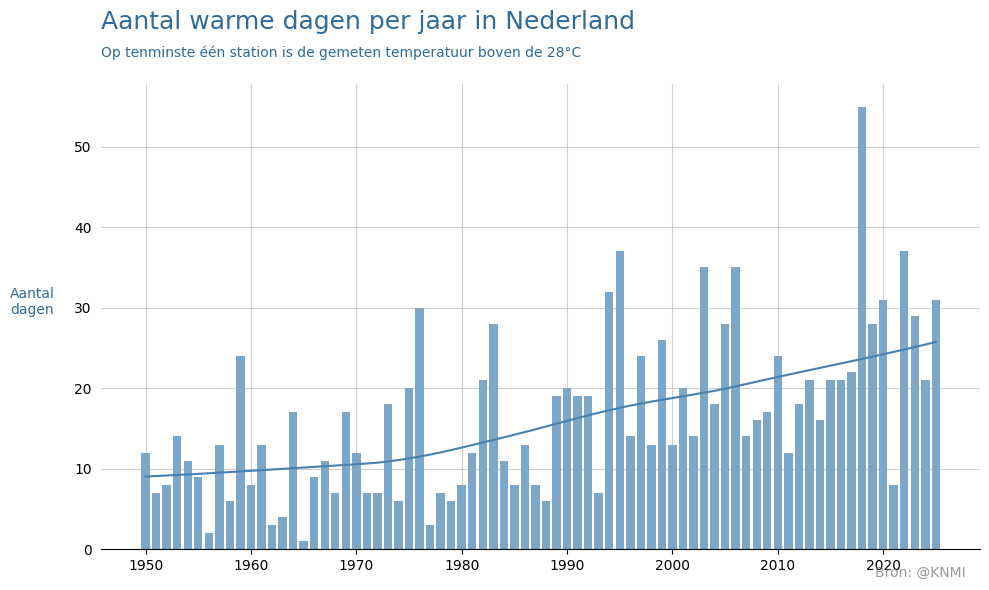

In [87]:
fig, ax = plt.subplots(figsize=(10,6))

# Bereken de LOWESS-trendlijn (gladde gemiddelde curve)
trend = lowess(data["TX"], data["datum"], frac=0.6)

# Staafdiagram voor de ruwe jaarlijkse aantallen
ax.bar(data["datum"], data["TX"], color="#7DA7C9", zorder=2)
# Trendlijn bovenop de staven
ax.plot(trend[:,0], trend[:,1], color="#4681AF", zorder=3)

ax.set_title("Aantal warme dagen per jaar in Nederland", fontsize=18, color="#306B99", loc="left", pad=40)
ax.text(0, 1.06, "Op tenminste één station is de gemeten temperatuur boven de 28°C",
        transform=ax.transAxes, fontsize=10, color="#306B99")

# Labels en opmaak
ax.set_ylabel("Aantal\ndagen", rotation=0, color="#306B99", labelpad=30)
ax.grid(axis="both", alpha=0.6, zorder=1)
ax.tick_params(axis="y", width=0)
ax.spines[["left", "top", "right"]].set_visible(False)
ax.text(0.88, -0.06, "Bron: @KNMI", transform = ax.transAxes, color="grey", alpha=0.8)

plt.savefig("temp.png", bbox_inches="tight")
plt.tight_layout()
plt.show()

## Resultaat en discussie

Bekijk de grafiek hierboven goed en beantwoord de volgende vragen:

1. **Zie je een duidelijke trend?** komen warme dagen vaker of juist minder vaak voor?
2. **Zijn er uitschieters?** Welke jaren springen eruit? Wat weet je van die zomers?
3. **Wat zijn mogelijke verklaringen** voor de trend die je ziet?
4. **Wat zijn de beperkingen** van deze analyse? Denk aan het aantal stations of de gekozen grens van 28 °C.

> **Extra:** Pas `STARTJAAR` of de grens van 28 °C aan in de code en kijk wat er verandert!

**4. Wat zijn de beperkingen van deze analyse? Denk aan het aantal stations of de gekozen grens van 28 °C.**

In [118]:
eerste_jaar = df.groupby("station")["datum"].min().dt.year
laatste_jaar = df.groupby("station")["datum"].max().dt.year

stations_volledig = eerste_jaar.index[(eerste_jaar == 1950) & (laatste_jaar == 2026)]
df_gefilterd = df[df["station"].isin(stations_volledig)]

# Selecteer per dag het maximum van alle stations.
dagmax_2 = df_gefilterd.groupby("datum")["TX"].max().reset_index()

# Tel per jaar hoeveel dagen de temepratuur boven de 28 graden celsius uit kwam
data_2 = dagmax_2.loc[dagmax_2["TX"] > 28].groupby(dagmax_2["datum"].dt.year)["TX"].count().reset_index()

In [119]:
stations_volledig

Index(['De Bilt', 'De Kooy Airport', 'Groningen Airport Eelde',
       'Maastricht Airport', 'Vlissingen'],
      dtype='str', name='station')

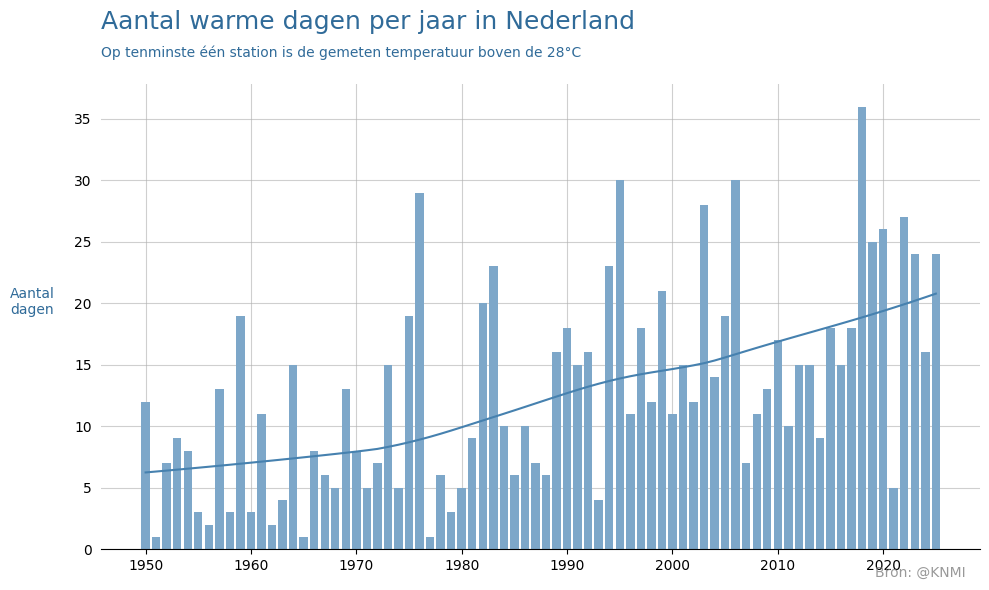

In [120]:
fig, ax = plt.subplots(figsize=(10,6))

# Bereken de LOWESS-trendlijn (gladde gemiddelde curve)
trend = lowess(data_2["TX"], data_2["datum"], frac=0.6)

# Staafdiagram voor de ruwe jaarlijkse aantallen
ax.bar(data_2["datum"], data_2["TX"], color="#7DA7C9", zorder=2)
# Trendlijn bovenop de staven
ax.plot(trend[:,0], trend[:,1], color="#4681AF", zorder=3)

ax.set_title("Aantal warme dagen per jaar in Nederland", fontsize=18, color="#306B99", loc="left", pad=40)
ax.text(0, 1.06, "Op tenminste één station is de gemeten temperatuur boven de 28°C",
        transform=ax.transAxes, fontsize=10, color="#306B99")

# Labels en opmaak
ax.set_ylabel("Aantal\ndagen", rotation=0, color="#306B99", labelpad=30)
ax.grid(axis="both", alpha=0.6, zorder=1)
ax.tick_params(axis="y", width=0)
ax.spines[["left", "top", "right"]].set_visible(False)
ax.text(0.88, -0.06, "Bron: @KNMI", transform = ax.transAxes, color="grey", alpha=0.8)

plt.savefig("temp.png", bbox_inches="tight")
plt.tight_layout()
plt.show()